# 03 · Train Swin-Small
Thin driver over the shared engine — the ONLY difference between 02/03/04 is the model key.

In [1]:
# === Preamble 1/2: environment & GPU report ===
# This is a REMOTE Colab kernel — it cannot see your local files.
import sys
print('Python:', sys.version.split()[0])
try:
    import torch
    print('PyTorch:', torch.__version__, '| CUDA:', torch.cuda.is_available())
    if torch.cuda.is_available():
        print('GPU:', torch.cuda.get_device_name(0))
        print('bfloat16 supported:', torch.cuda.is_bf16_supported())
    else:
        print('No GPU — Runtime > Change runtime type > A100 (or L4).')
except ImportError:
    print('torch installs in the next cell.')

Python: 3.12.13
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA A100-SXM4-40GB
bfloat16 supported: True


In [2]:
# === Preamble 2/2: clone-or-pull + install (+ optional autoreload) ===
import os, subprocess, sys

REPO_URL = "https://github.com/Kidhurshan/plant-leaf-classifier.git"  # <-- EDIT to your repo
REPO_DIR = "/content/plant-leaf-classifier"
# Private repo? use https://<TOKEN>@github.com/Kidhurshan/plant-leaf-classifier.git

if not os.path.isdir(REPO_DIR):
    print('Cloning', REPO_URL)
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r',
                'requirements.txt'], check=True)

# Hot-reload src/ after a `git pull` (optional convenience; never fatal).
try:
    from IPython import get_ipython
    _ip = get_ipython()
    _ip.run_line_magic('load_ext', 'autoreload')
    _ip.run_line_magic('autoreload', '2')
    print('autoreload enabled.')
except Exception as _e:
    print('autoreload not enabled (non-fatal):', repr(_e))

from src.utils import sync_repo, gpu_report
sync_repo()   # git pull + print the commit hash these results are traceable to
gpu_report()

autoreload not enabled (non-fatal): ModuleNotFoundError("No module named 'imp'")
Syncing repository (git pull)...
From https://github.com/Kidhurshan/plant-leaf-classifier
   b4347bf..1a7302d  main       -> origin/main
Updating b4347bf..1a7302d
Fast-forward
 notebooks/01_setup_and_data.ipynb        |  44 +++++----
 notebooks/02_train_efficientnetv2s.ipynb | 150 ++++++++++++++++++++++---------
 notebooks/03_train_swin_small.ipynb      |  18 ++++
 notebooks/04_train_cbam_convnext.ipynb   |  18 ++++
 notebooks/05_compare_and_ensemble.ipynb  |  10 ++-
 5 files changed, 177 insertions(+), 63 deletions(-)
Now running code at commit: 1a7302d [DIRTY WORKING TREE]

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
!! The pull brought NEW CODE into this runtime.
!! %autoreload CANNOT reload changed classes/dataclasses.
!! -> RESTART THE KERNEL now, then run the notebook from the top.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
ENVIRONMENT
  Python      

{'python': '3.12.13',
 'torch': '2.11.0+cu128',
 'cuda_available': True,
 'gpu': 'NVIDIA A100-SXM4-40GB',
 'vram_gb': 39.5,
 'cuda_version': '12.8',
 'bf16_supported': True}

## Why this architecture
**Swin-Small** is a hierarchical vision transformer using *shifted windows*: self-attention within local windows that shift between blocks to mix information globally, giving transformer-style long-range context at CNN-like cost. It is fixed at 224×224 by its window-7 design.

## Config, model summary & shape check

In [3]:
from src.config import load_config
from src.utils import set_seed, detect_amp
from src.models import build_model, describe_model
import torch

SMOKE = False   # True -> ~200 imgs, 1+1 epochs, <5 min (needs nb 01 smoke cache)
MODEL = 'swin_small'
cfg = load_config('configs/default.yaml')
cfg.paths.ensure_dirs()
set_seed(cfg.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

_m = build_model(cfg, MODEL, device=device)
print(describe_model(_m))
with torch.no_grad():
    _o = _m(torch.randn(2, 3, cfg.data.img_size, cfg.data.img_size, device=device))
assert tuple(_o.shape) == (2, cfg.data.num_classes), _o.shape
print('shape check OK:', tuple(_o.shape))
del _m  # train_model builds its own fresh copy

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B /  200MB            

model.safetensors: downloading bytes:           |  0.00B            

08:26:58 | INFO    | Built 'swin_small' (backbone=swin_small_patch4_window7_224.ms_in22k_ft_in1k, cbam=False): 48.8M params (48.8M trainable).
Backbone      : swin_small_patch4_window7_224.ms_in22k_ft_in1k
CBAM          : False (0 module(s))
Feature dim   : 768
Total params  : 48,844,946 (48.8M)
Trainable     : 48,844,946 (48.8M)
Top-level modules:
  - backbone       SwinTransformer         48.8M params
  - cbam_modules   ModuleList                  0 params
  - head           SharedHead               7.7K params
shape check OK: (2, 8)


In [4]:
# --- Persist cache + checkpoints on Google Drive (survives runtime deletion) ---
from src.utils import use_drive_paths
import os

use_drive_paths(cfg)   # repoints cfg.paths.cache_dir AND cfg.paths.checkpoint_dir

print('cache_dir      :', cfg.paths.cache_dir)
print('checkpoint_dir :', cfg.paths.checkpoint_dir)
print('existing ckpts :', sorted(os.listdir(cfg.paths.checkpoint_dir)) or '(none - will train from scratch)')

[drive] cache_dir      -> /content/drive/MyDrive/task4_egypli/cache
[drive] checkpoint_dir -> /content/drive/MyDrive/task4_egypli/checkpoints
cache_dir      : /content/drive/MyDrive/task4_egypli/cache
checkpoint_dir : /content/drive/MyDrive/task4_egypli/checkpoints
existing ckpts : ['efficientnetv2s_best.pt', 'efficientnetv2s_last.pt']


## Preview one augmented image

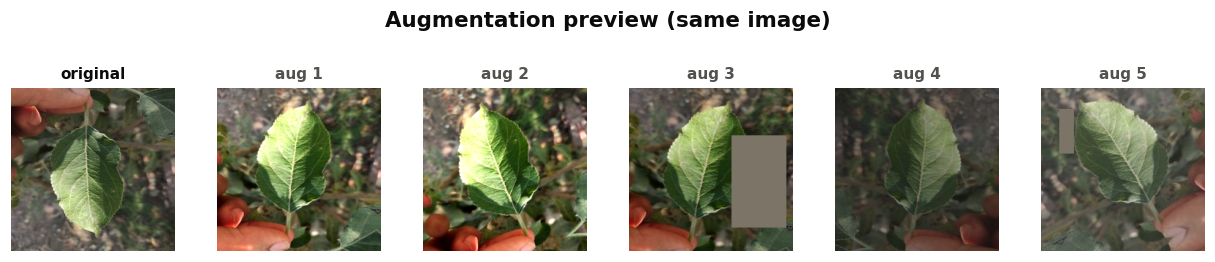

In [5]:
from src.data import prepare_datasets
from src.augment import GPUAugment, denormalize
from src import viz
datasets, class_names = prepare_datasets(cfg, device, smoke=SMOKE)
aug = GPUAugment(cfg.augment, cfg.data.img_size, device, training=True)
one = datasets['train'].images[datasets['train'].indices[0]].unsqueeze(0)
viz.plot_augmentation_preview(viz.to_hwc_uint8(one[0]),
                              [denormalize(aug(one))[0] for _ in range(5)]);

## Train — phase 1 (frozen backbone) then phase 2 (fine-tune all)
Watch the live per-epoch log; a total-runtime estimate prints after epoch 1.

In [6]:
from src.engine import train_model
res = train_model(cfg, MODEL, datasets, device, smoke=SMOKE,
                  class_names=class_names)
print('Best val macro-F1:', round(res['best_val_macro_f1'], 4))

08:27:04 | INFO    | Built 'swin_small' (backbone=swin_small_patch4_window7_224.ms_in22k_ft_in1k, cbam=False): 48.8M params (48.8M trainable).
08:27:04 | INFO    | Train class counts: [363, 238, 356, 364, 383, 328, 369, 111]

=== swin_small: PHASE 1 (frozen backbone, 5 epochs) ===
  [P1 E01] train_loss=0.2482 val_loss=0.0120 val_acc=0.9944 val_f1=0.9925 lr=1.00e-03 (2.4s)
    * new best macro-F1=0.9925 -> saved swin_small_best.pt
  >> Estimated total training time: ~1m 35s (40 planned epochs @ 2.4s/epoch).
  [P1 E02] train_loss=0.0132 val_loss=0.0067 val_acc=0.9981 val_f1=0.9966 lr=1.00e-03 (2.0s)
    * new best macro-F1=0.9966 -> saved swin_small_best.pt
  [P1 E03] train_loss=0.0050 val_loss=0.0060 val_acc=0.9963 val_f1=0.9945 lr=1.00e-03 (2.0s)
  [P1 E04] train_loss=0.0052 val_loss=0.0030 val_acc=0.9981 val_f1=0.9966 lr=1.00e-03 (2.0s)
  [P1 E05] train_loss=0.0032 val_loss=0.0046 val_acc=0.9981 val_f1=0.9966 lr=1.00e-03 (2.1s)

=== swin_small: PHASE 2 (fine-tune all, up to 35 epochs)

## Training curves (visual 4)

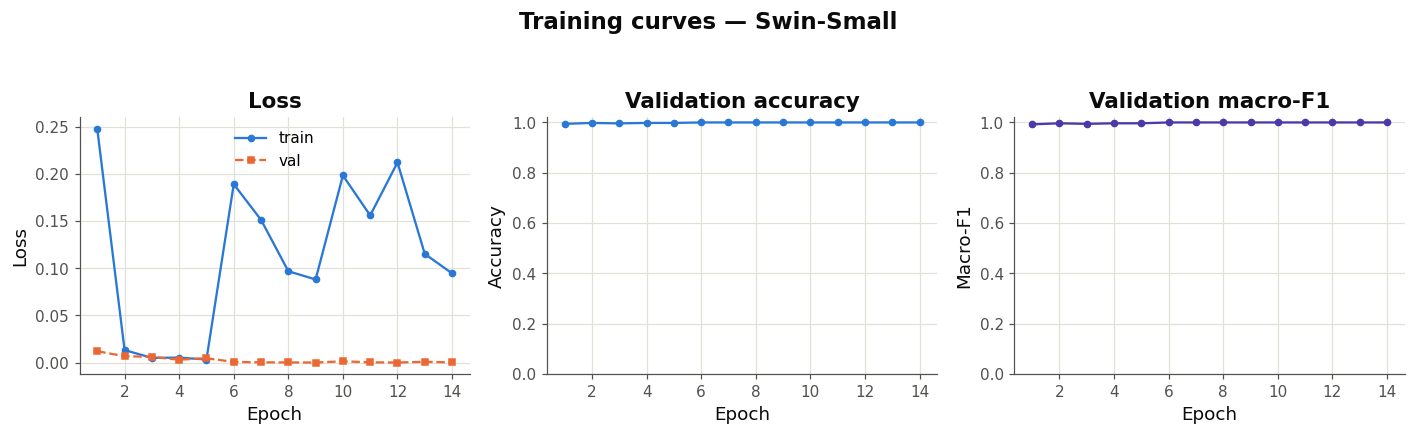

In [7]:
viz.plot_training_curves(res['history'], MODEL,
    out_path=f"{cfg.paths.figures_dir}/{MODEL}_curves.png");

## Validation confusion matrix

08:28:15 | INFO    | Eval: acc=1.0000 macro-F1=1.0000
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        78
       berry     1.0000    1.0000    1.0000        51
         fig     1.0000    1.0000    1.0000        76
       guava     1.0000    1.0000    1.0000        78
      orange     1.0000    1.0000    1.0000        82
        palm     1.0000    1.0000    1.0000        70
   persimmon     1.0000    1.0000    1.0000        79
      tomato     1.0000    1.0000    1.0000        24

    accuracy                         1.0000       538
   macro avg     1.0000    1.0000    1.0000       538
weighted avg     1.0000    1.0000    1.0000       538



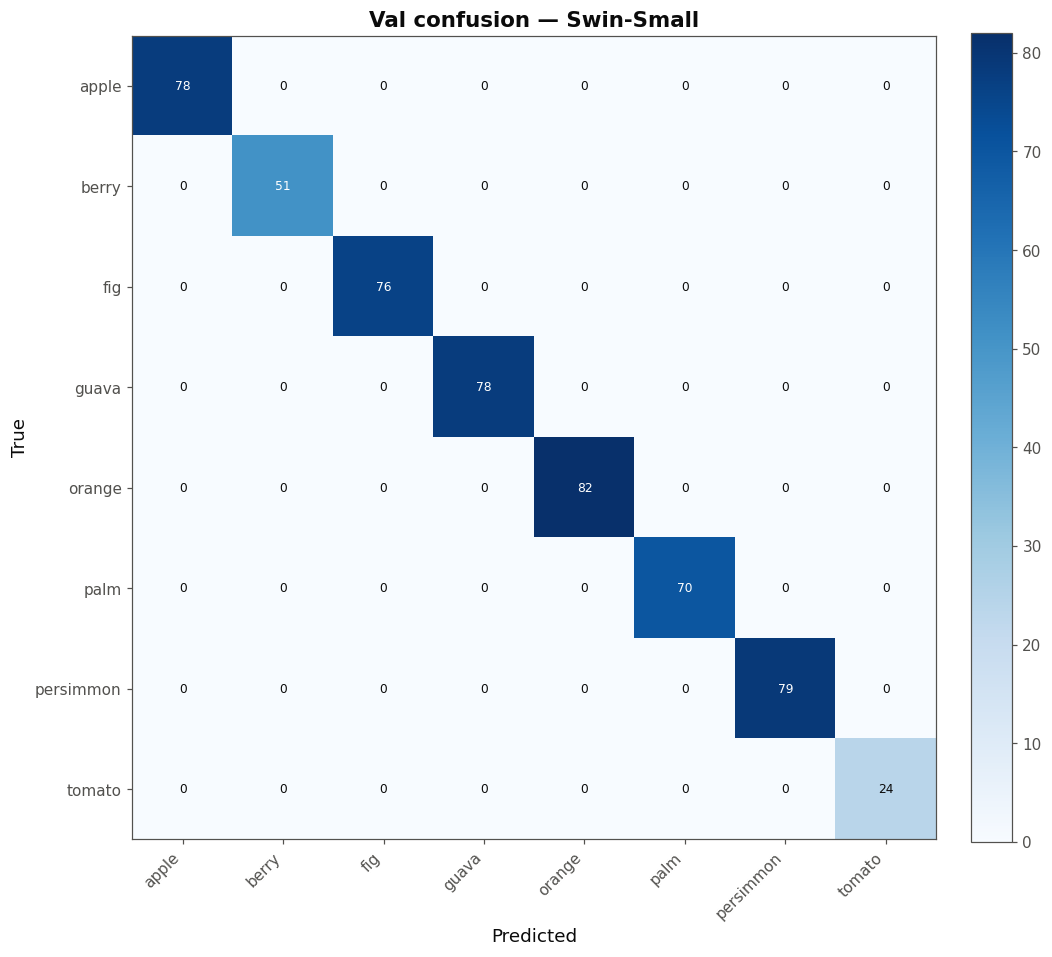

In [8]:
from src.evaluate import evaluate_model
from src.utils import detect_amp
aug_eval = GPUAugment(cfg.augment, cfg.data.img_size, device, training=False)
bs = cfg.smoke.batch_size if SMOKE else cfg.train.batch_size
m = evaluate_model(res['model'], datasets['val'], aug_eval,
                   detect_amp(device), bs, class_names)
viz.plot_confusion_matrix(m['confusion_matrix'], class_names,
    out_path=f"{cfg.paths.figures_dir}/{MODEL}_val_confusion.png",
    title=f'Val confusion — {viz.display_name(MODEL)}')
print(m['report'])

## Outputs

In [9]:
print('checkpoint ->', res['best_checkpoint'])
print('history    ->', res['history_csv'])
print('figures    ->', cfg.paths.figures_dir)

checkpoint -> /content/drive/MyDrive/task4_egypli/checkpoints/swin_small_best.pt
history    -> results/metrics/swin_small_history.csv
figures    -> results/figures


---
### ⚠️ When finished: disconnect and DELETE the runtime
`Runtime > Disconnect and delete runtime`. Colab compute units are consumed the whole time a runtime is connected.